In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')

#Data Read
file_path = 'heart_disease_uci.csv'
df = pd.read_csv(file_path, na_values='?')

Feature Importances:
                     Feature  Importance
2                       chol    0.141198
4                     thalch    0.121411
6                    oldpeak    0.112081
0                        age    0.110586
5                      exang    0.097751
1                   trestbps    0.077798
9         cp_atypical angina    0.077504
7                         ca    0.052576
8                   sex_Male    0.039754
10            cp_non-anginal    0.033491
16               thal_normal    0.030670
17    thal_reversable defect    0.018727
12            restecg_normal    0.017971
3                        fbs    0.016506
15           slope_upsloping    0.013714
11         cp_typical angina    0.013493
13  restecg_st-t abnormality    0.012885
14                slope_flat    0.011883


-----------------------------------------
Generating Feature Importance plot...
-----------------------------------------


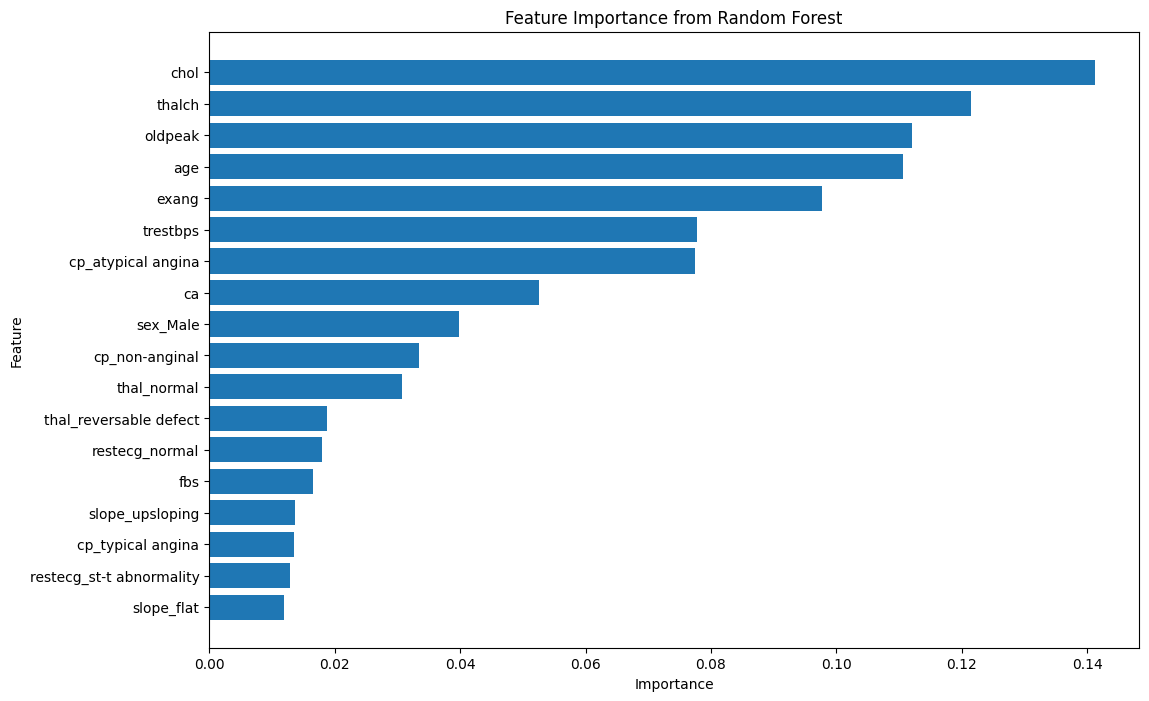

In [ ]:
#Handle Missing Values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
        else:
            mean_value = df[col].mean()
            df[col].fillna(mean_value, inplace=True)

#Data Encoding
df_processed = df.drop(['id', 'dataset'], axis=1)
df_processed.rename(columns={'num': 'target'}, inplace=True)
df_processed['target'] = (df_processed['target'] > 0).astype(int)

categorical_cols = df_processed.select_dtypes(include=['object']).columns
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

#Separate features (X) and target (y)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled_df, y)

#Feature importances
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)
print("\n")


#Visualize Feature Importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.show()
